# Default Classification Scheme Implementation

In [1]:
# Load luma-stack package
!python -m pip install .. --quiet

# Load libraries
import ee
import os
import geemap
import pandas as pd
import numpy as np
import importlib
import default_scheme
import rasterio
from rasterio.mask import mask
from rasterio.transform import from_bounds
from rasterio.enums import Resampling
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Load the default_scheme functions   
importlib.reload(default_scheme)

from default_scheme import (
    read_mosaic_rast,
    read_classification_scheme,
    build_mapping,
    aggregate_probability,
    predict_class,
    resample_predictors_to_probability_grid,
    build_validity_stack,
    predict_class_ruleset,
    plot_classification_summary,
    plot_ruleset_comparison
)


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Earth Engine initialization
ee.Authenticate()
ee.Initialize()

## Step 1: Define Inputs & Parameters

In [3]:
# Define input file path
aoi_path = "../data/modular_mapping_approach/aceh_test/aceh_aoi1.shp"
multi_prob_map_path = "projects/epistem2/assets/probability_stack_Aceh_2020"
predictors_map_path = "D:/aceh_test/predictors_composite_aceh_f.tif"
modified_scheme_path = "../data/modular_mapping_approach/aceh_test/modified_scheme.xlsx"
ruleset_path = "../data/modular_mapping_approach/aceh_test/predictors_ruleset.xlsx"
year = 2020
Class_path = "../data/modular_mapping_approach/aceh_test/output"


## Step 2: Load & Clip Map Input with AOI

In [4]:
# Load AOI
aoi_ee = geemap.shp_to_ee(aoi_path)
aoi_gdf = gpd.read_file(aoi_path) 

# Load and clip multi-probability map  
raster_multi_prob, out_transform_prob, raster_meta_multi_prob, band_names_prob = read_mosaic_rast(multi_prob_map_path, aoi_gdf)

print('Available multi-probability map bands:')
for name in band_names_prob:
    print(f' - {name}')
    
# Load and clip predictors map
raster_multi_pred, out_transform_pred, raster_meta_pred, band_names_pred = read_mosaic_rast(predictors_map_path, aoi_gdf)

print('Available predictors map bands:')
for name in band_names_pred:
   print(f' - {name}')

Available multi-probability map bands:
 - constant
 - prob_18
 - prob_2
 - prob_4
 - prob_23
 - prob_20
 - prob_1
 - prob_17
 - prob_24
 - prob_9
 - prob_13
Available predictors map bands:
 - aceh_dem_30m
 - aceh_dist_to_coast_100m
 - aceh_slope_30m_deg
 - aceh_worldpop_2020_30m_ne


## Step 3: Define Classification Scheme & Required Probability Bands

In [5]:
# Read scheme 
modified_scheme = pd.read_excel(modified_scheme_path)

# Define selected scheme
scheme = read_classification_scheme(modified_scheme)

# Build aggregation mapping
mapping = build_mapping(scheme)

# Aggregate probability cube
aggregated_cube, output_info = aggregate_probability(
    raster_multi_prob,
    mapping,
    band_names_prob
)

output_info

,Class_ID,Class_Name,Class_Level,Color,Band_IDs,Band_Names
0,1,Hutan Lahan Kering Primer,3,#006400,[6],[prob_1]
1,2,Hutan Lahan Kering Sekunder,3,#228B22,[2],[prob_2]
2,3,Hutan Mangrove Primer,3,#006D5B,[],[]
3,4,Hutan Mangrove Sekunder,3,#20A080,[3],[prob_4]
4,5,Hutan Rawa Primer,3,#004D40,[],[]
5,6,Hutan Rawa Sekunder,3,#00897B,[],[]
6,7,Hutan Tanaman,3,#4C9A2A,[],[]
7,8,Monokultur Karet,3,#7FBF3F,[],[]
8,9,Monokultur Kelapa Sawit,3,#B8C900,[9],[prob_9]
9,10,Monokultur Kakao,3,#8B6914,[],[]


## Step 4: Apply Argmax and Predictors Ruleset to Produce Final Classification

In [6]:
# Read and index the ruleset
ruleset_df = pd.read_excel(ruleset_path, na_values=['-', ''])
ruleset_df = ruleset_df.set_index("Class_ID", drop=False)  

# Raw argmax classification
raw_map, raw_meta, raw_maxprob, raw_argmax, class_ids = predict_class(
    aggregated_cube, output_info, raster_meta_multi_prob
)

# Resample predictors to the probability grid
pred_grid = resample_predictors_to_probability_grid(
    raster_multi_pred, 
    raster_meta_pred, 
    raster_meta_multi_prob, 
    resampling=Resampling.average
)

# Build validity stack
# Use the default prefix mapping
from default_scheme import DEFAULT_PREDICTOR_MAP   
predictor_map = DEFAULT_PREDICTOR_MAP   

valid = build_validity_stack(
    pred_grid, 
    band_names_pred, 
    class_ids,
    ruleset_df, 
    predictor_map
)

# Apply rule‑based refinement
result = predict_class_ruleset(
    valid, aggregated_cube, raw_argmax, raw_maxprob, raw_map, raw_meta, class_ids
)

Note: 1588 pixel(s) with no valid class; fallback to raw argmax.
Ruleset changed 825 pixels (1.38% of tile).


## Step 5: Final Classification Visualisation

Class distribution:
    Class_ID                    Class_Name  Pixel_Count  Percentage
0         0           Background / NoData         6238   10.434928
1         1    Hutan Lahan Kering Primer          1904    3.185012
2         2  Hutan Lahan Kering Sekunder          2402    4.018066
3        18              Rumput / Savana         34345   57.452325
4        20                   Permukiman         14343   23.992974
5        23                    Badan Air           548    0.916695
Ruleset changed 825 pixels (1.38%)


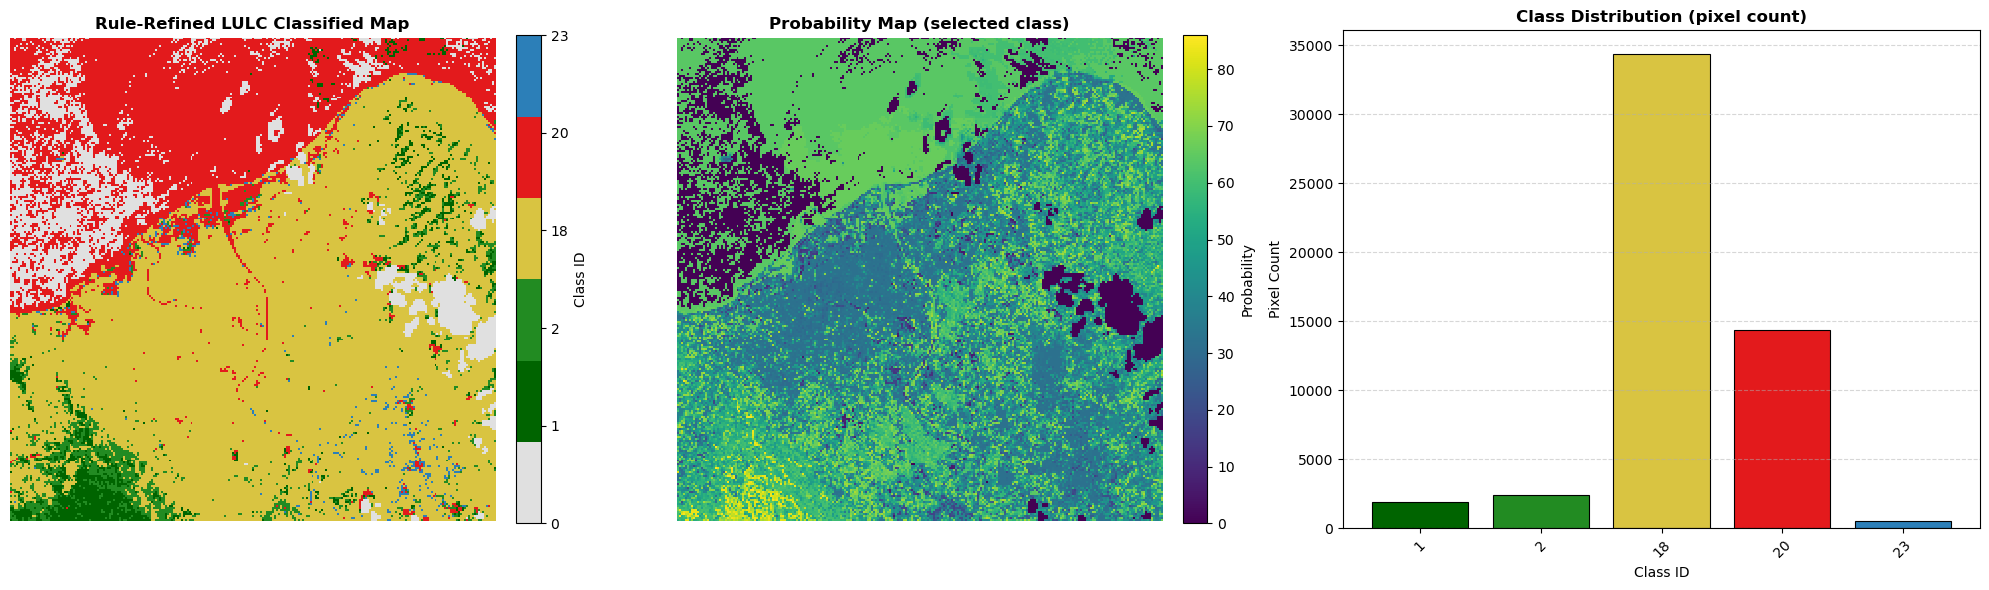

In [7]:
# Visualize the classified map and maximum probability map
pixel_summary = plot_classification_summary(
        classified_map=result["classified_map"],
        max_prob_map=result["max_prob_map"],
        output_info=output_info,
        save_path="../data/modular_mapping_approach/aceh_test/aceh_classified_map_ruleset.png",
        title="Rule-Refined LULC Classified Map",
        corrected_mask=result["corrected_mask"],
    )

Raw vs corrected:
    Class_ID                    Class_Name  Raw_Count  Corrected_Count  Change
0         0           Background / NoData       6238             6238       0
1         1    Hutan Lahan Kering Primer        1994             1904     -90
2         2  Hutan Lahan Kering Sekunder        2766             2402    -364
3        18              Rumput / Savana       33685            34345     660
4        20                   Permukiman       14178            14343     165
5        23                    Badan Air         919              548    -371
825 pixels changed (1.38%)
1588 pixels with no valid class (fallback) (2.66%)


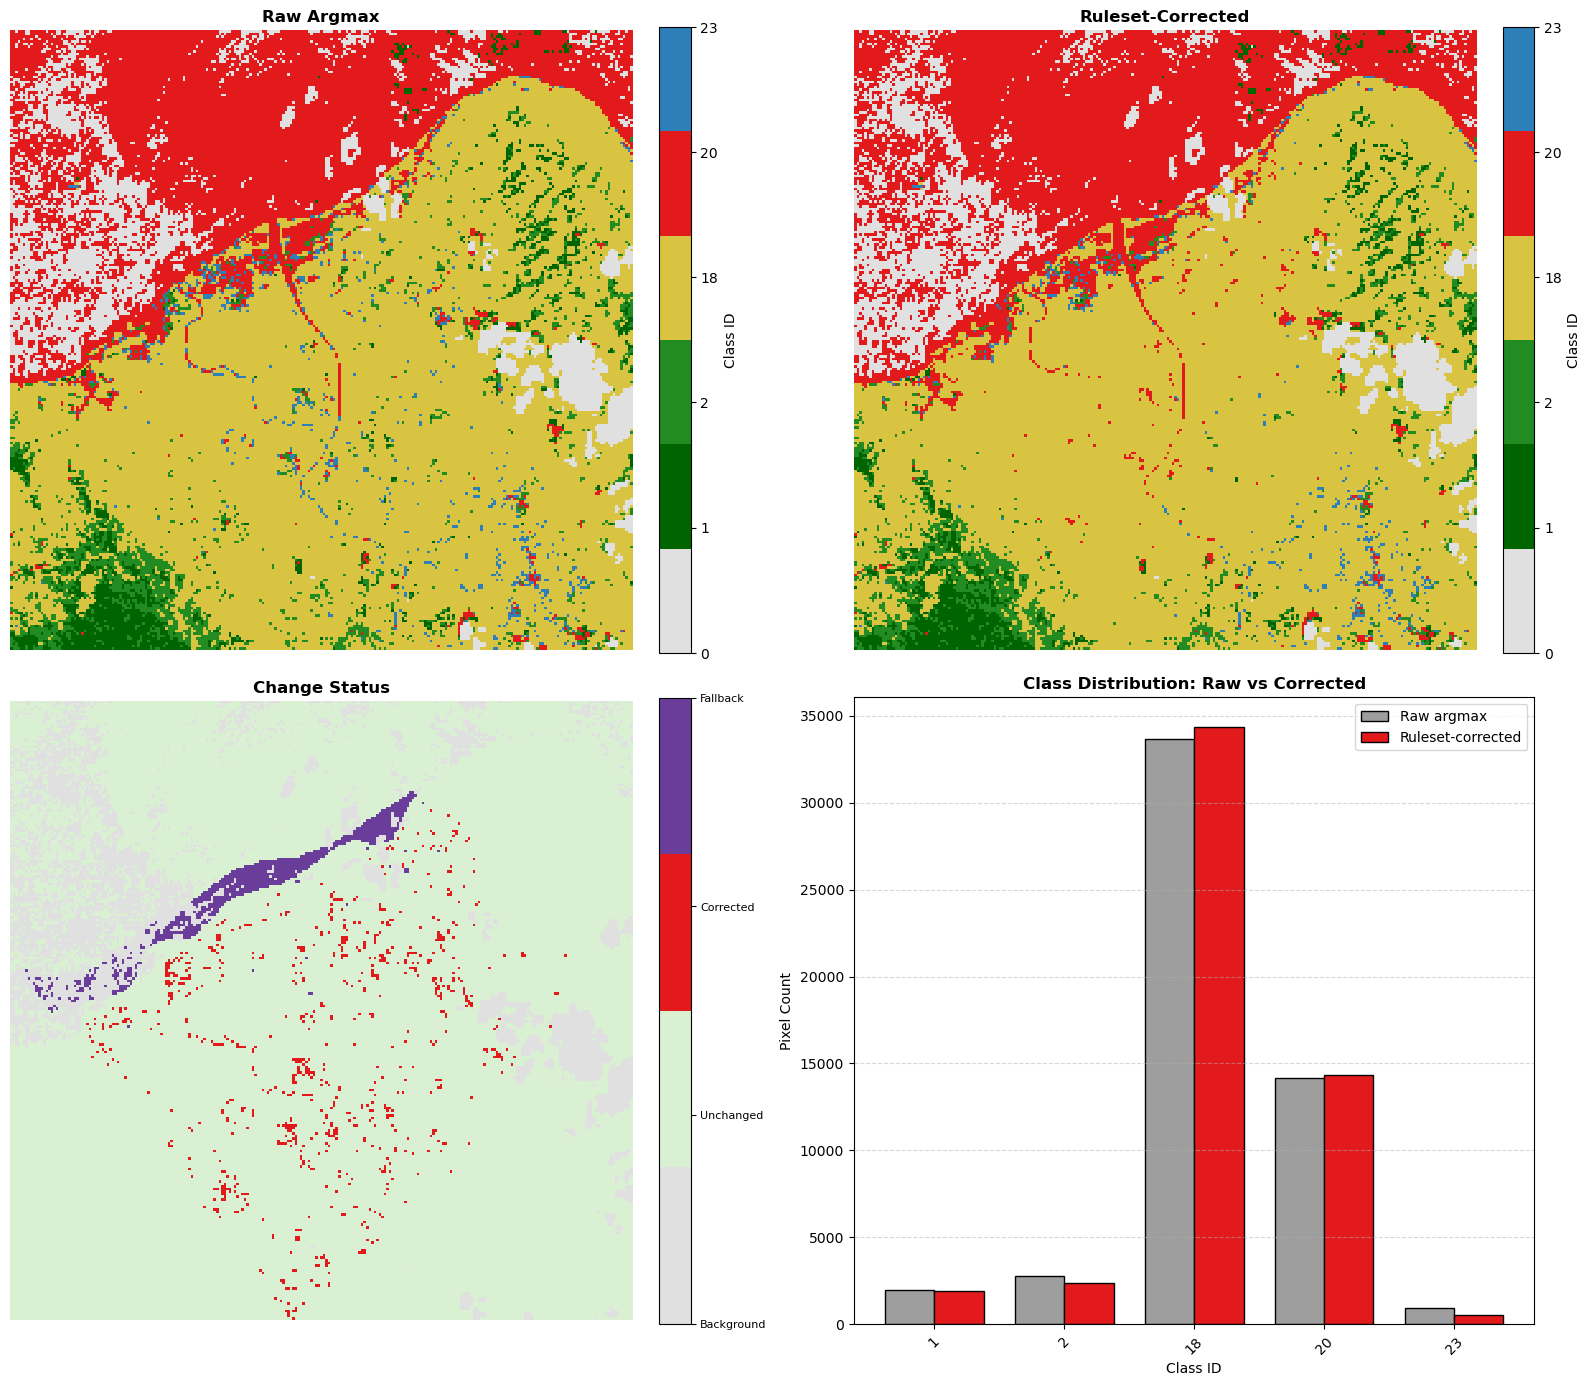

In [8]:
# Plot comparison result of the classification with maximum probability and predictor ruleset
comparison_table = plot_ruleset_comparison(
        result, output_info,
        save_path="../data/modular_mapping_approach/aceh_test/aceh_ruleset_comparison.png",
    )

## Step 6: Export Final Map

In [9]:
# # Define output directory and file name
# os.makedirs(output_path, exist_ok=True)
# output_file = os.path.join(output_path, "muba_classified_map.tif")

# # Get geometry properties from AOI as reference 
# minx, miny, maxx, maxy = aoi_gdf.total_bounds  
# crs = aoi_gdf.crs 
# height, width = classified_map.shape
# transform = from_bounds(minx, miny, maxx, maxy, width, height)

# profile = {
#     'driver': 'GTiff',
#     'height': height,
#     'width': width,
#     'count': 1,
#     'dtype': rasterio.int32,
#     'crs': crs,
#     'transform': transform,
#     'compress': 'lzw',    
#     'nodata': 0           
# }

# # Export
# with rasterio.open(output_file, 'w', **profile) as dst:
#     dst.write(classified_map.astype(np.int32), 1)